In [359]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE, ADASYN

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [360]:
data_train = pd.read_excel('Data_Set_(A+B).xlsx')
data_test  = pd.read_excel('Data_Set_C.xlsx')

# Удаляем строки с NaN из обеих выборок
print(f"Исходный размер A+B: {data_train.shape}")
data_train = data_train.dropna().reset_index(drop=True)
print(f"После удаления NaN: {data_train.shape}")

print(f"Исходный размер C: {data_test.shape}")
data_test = data_test.dropna().reset_index(drop=True)
print(f"После удаления NaN: {data_test.shape}")

print("Обучающая A+B:", data_train.shape)
print("Контрольная C:", data_test.shape)

TARGET_TYPE = 2   # измените по своему варианту
data_train['Y'] = (data_train['Type'] == TARGET_TYPE).astype(int)
data_test['Y']  = (data_test['Type'] == TARGET_TYPE).astype(int)

print("\nРаспределение классов в обучающей выборке:")
print(data_train['Y'].value_counts())
print("\nРаспределение в контрольной выборке:")
print(data_test['Y'].value_counts())

Исходный размер A+B: (176, 27)
После удаления NaN: (169, 27)
Исходный размер C: (58, 27)
После удаления NaN: (56, 27)
Обучающая A+B: (169, 27)
Контрольная C: (56, 27)

Распределение классов в обучающей выборке:
Y
0    133
1     36
Name: count, dtype: int64

Распределение в контрольной выборке:
Y
0    44
1    12
Name: count, dtype: int64


In [361]:
feature_columns = ['Vx', 'Vy', 'omega', 'Ix', 'Iy', 'If','Is', 'Tx', 'Ty', 'Tf', 'Tz']
# Оставляем только существующие столбцы
feature_columns = [c for c in feature_columns if c in data_train.columns]
print("Используемые признаки:", feature_columns)

X_full = data_train[feature_columns].copy()
y_full = data_train['Y'].copy()
X_test = data_test[feature_columns].copy()
y_test = data_test['Y'].copy()

# Разделение A+B на обучение (60%) и валидацию (40%) – стратифицированно
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.4, stratify=y_full, random_state=RANDOM_STATE
)
print(f"Размеры: Train {X_train.shape[0]}, Val {X_val.shape[0]}, Test {X_test.shape[0]}")

Используемые признаки: ['Vx', 'Vy', 'omega', 'Ix', 'Iy', 'If', 'Is', 'Tx', 'Ty', 'Tf', 'Tz']
Размеры: Train 101, Val 68, Test 56


In [362]:
def evaluate_and_plot(model, X_tr, y_tr, X_v, y_v, name, plot_points=200):
    """
    Обучает модель на (X_tr, y_tr), оценивает на (X_v, y_v),
    выводит метрики train/val, строит график сравнения, матрицу ошибок, кривые обучения.
    Возвращает словарь с метриками.
    """
    # Кросс-валидация на тренировочной выборке (можно добавить, но для скорости оставим)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=4, scoring='accuracy')
    
    # Обучение
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_v = model.predict(X_v)
    
    acc_tr = accuracy_score(y_tr, y_pred_tr)
    f1_tr = f1_score(y_tr, y_pred_tr)
    acc_v = accuracy_score(y_v, y_pred_v)
    f1_v = f1_score(y_v, y_pred_v)
    
    print(f"\n--- {name} ---")
    print(f"Параметры: hls={model.hidden_layer_sizes}, act={model.activation}, solver={model.solver}")
    print(f"CV Accuracy (train): mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")
    print(f"Train: Accuracy={acc_tr:.4f}, F1={f1_tr:.4f}")
    print(f"Val:   Accuracy={acc_v:.4f}, F1={f1_v:.4f}")
    
    # График сравнения на валидации
    plt.figure(figsize=(12,4))
    n = min(plot_points, len(y_v))
    plt.plot(y_v.values[:n] if hasattr(y_v, 'values') else y_v[:n], 'o-', label='Истинные', alpha=0.7, markersize=4)
    plt.plot(y_pred_v[:n], 'x--', label='Предсказанные', alpha=0.7, markersize=4)
    plt.title(f'{name} (валидация, первые {n} точек)')
    plt.xlabel('Индекс примера'); plt.ylabel('Класс')
    plt.legend(); plt.grid(True); plt.show()
    
    # Матрица ошибок на валидации
    cm = confusion_matrix(y_v, y_pred_v)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Другие', f'Тип {TARGET_TYPE}'],
                yticklabels=['Другие', f'Тип {TARGET_TYPE}'])
    plt.title(f'{name}: матрица ошибок (валидация)')
    plt.show()
    
    # Кривые обучения (если есть)
    if hasattr(model, 'loss_curve_') and len(model.loss_curve_):
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1); plt.plot(model.loss_curve_); plt.title('Loss (обучение)'); plt.grid(True)
        if hasattr(model, 'validation_scores_') and len(model.validation_scores_):
            plt.subplot(1,2,2); plt.plot(model.validation_scores_); plt.title('Val accuracy (early stopping)'); plt.grid(True)
        plt.suptitle(f'{name}: кривые обучения'); plt.tight_layout(); plt.show()
    
    return {
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'acc_tr': acc_tr, 'f1_tr': f1_tr,
        'acc_v': acc_v, 'f1_v': f1_v
    }

In [363]:
configs = [
    {'hidden_layer_sizes': (50,),   'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
    {'hidden_layer_sizes': (50,50), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,),  'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,50),'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
    
    {'hidden_layer_sizes': (50,),   'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
    {'hidden_layer_sizes': (50,50), 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,),  'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,50),'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
    
    {'hidden_layer_sizes': (50,),   'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
    {'hidden_layer_sizes': (50,50), 'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,),  'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,50),'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
    
    {'hidden_layer_sizes': (50,),   'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
    {'hidden_layer_sizes': (50,50), 'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,),  'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,50),'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
    
    {'hidden_layer_sizes': (50,),   'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
    {'hidden_layer_sizes': (50,50), 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,),  'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,50),'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
    
    {'hidden_layer_sizes': (50,),   'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
    {'hidden_layer_sizes': (50,50), 'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,),  'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
    {'hidden_layer_sizes': (100,50),'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
]

In [364]:
# configs = [
#     {'hidden_layer_sizes': (10,),   'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
#     {'hidden_layer_sizes': (10,10), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,),  'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,10),'activation': 'tanh', 'solver': 'adam', 'max_iter': 10000},
    
#     {'hidden_layer_sizes': (10,),   'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
#     {'hidden_layer_sizes': (10,10), 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,),  'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,10),'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 10000},
    
#     {'hidden_layer_sizes': (10,),   'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
#     {'hidden_layer_sizes': (10,10), 'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,),  'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,10),'activation': 'tanh', 'solver': 'sgd', 'max_iter': 10000},
    
#     {'hidden_layer_sizes': (10,),   'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
#     {'hidden_layer_sizes': (10,10), 'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,),  'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,10),'activation': 'relu', 'solver': 'adam', 'max_iter': 10000},
    
#     {'hidden_layer_sizes': (10,),   'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
#     {'hidden_layer_sizes': (10,10), 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,),  'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,10),'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 10000},
    
#     {'hidden_layer_sizes': (10,),   'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
#     {'hidden_layer_sizes': (10,10), 'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,),  'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
#     {'hidden_layer_sizes': (20,10),'activation': 'relu', 'solver': 'sgd', 'max_iter': 10000},
# ]

hp_results = []  # для хранения (cfg_name, cv_f1, f1_val)

for cfg in configs:
    model = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation=cfg['activation'],
        solver=cfg['solver'],
        max_iter=cfg['max_iter'],
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
    # Кросс-валидация на тренировочной выборке
    cv_f1 = cross_val_score(model, X_train, y_train, cv=4, scoring='f1').mean()
    # Обучение и оценка на валидации
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    f1_val = f1_score(y_val, y_pred_val)
    acc_val = accuracy_score(y_val, y_pred_val)
    cfg_name = f"hls={cfg['hidden_layer_sizes']}, act={cfg['activation']}, sol={cfg['solver']}"
    hp_results.append((cfg_name, cv_f1, f1_val, acc_val, cfg))
    print(f"{cfg_name:40} | CV F1={cv_f1:.4f} | Val Acc={acc_val:.4f} | Val F1={f1_val:.4f}")

# Лучшая конфигурация по валидационному F1
best_hp = max(hp_results, key=lambda x: x[2])
best_cfg = best_hp[4]
print(f"\nЛучшая конфигурация: {best_hp[0]}, Val F1={best_hp[2]:.4f}")

hls=(50,), act=tanh, sol=adam            | CV F1=0.3660 | Val Acc=0.2794 | Val F1=0.3636
hls=(50, 50), act=tanh, sol=adam         | CV F1=0.0000 | Val Acc=0.7794 | Val F1=0.0000
hls=(100,), act=tanh, sol=adam           | CV F1=0.4147 | Val Acc=0.5294 | Val F1=0.3043
hls=(100, 50), act=tanh, sol=adam        | CV F1=0.4422 | Val Acc=0.7941 | Val F1=0.4167
hls=(50,), act=tanh, sol=lbfgs           | CV F1=0.6659 | Val Acc=0.9118 | Val F1=0.7857
hls=(50, 50), act=tanh, sol=lbfgs        | CV F1=0.7349 | Val Acc=0.8824 | Val F1=0.7143
hls=(100,), act=tanh, sol=lbfgs          | CV F1=0.5453 | Val Acc=0.8971 | Val F1=0.7407
hls=(100, 50), act=tanh, sol=lbfgs       | CV F1=0.5756 | Val Acc=0.8824 | Val F1=0.6923
hls=(50,), act=tanh, sol=sgd             | CV F1=0.3496 | Val Acc=0.6912 | Val F1=0.3226
hls=(50, 50), act=tanh, sol=sgd          | CV F1=0.0625 | Val Acc=0.7500 | Val F1=0.1053
hls=(100,), act=tanh, sol=sgd            | CV F1=0.3667 | Val Acc=0.5000 | Val F1=0.3200
hls=(100, 50), act=ta

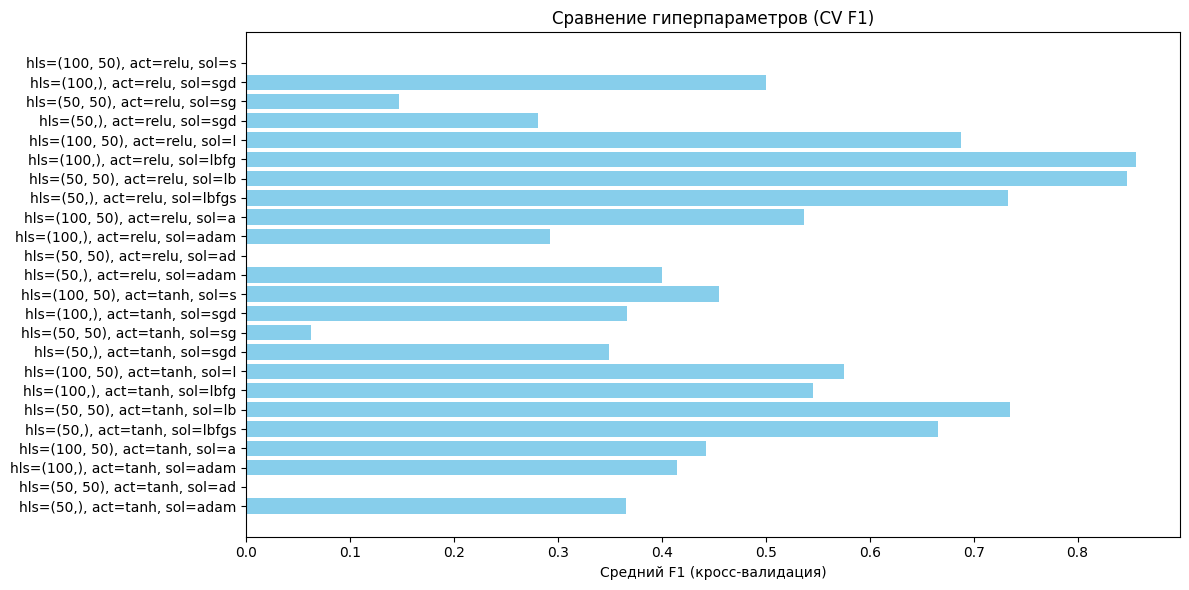

In [365]:
plt.figure(figsize=(12,6))
names = [x[0][:30] for x in hp_results]
cv_scores = [x[1] for x in hp_results]
plt.barh(names, cv_scores, color='skyblue')
plt.xlabel('Средний F1 (кросс-валидация)')
plt.title('Сравнение гиперпараметров (CV F1)')
plt.tight_layout()
plt.savefig('hyperparams_cv_f1.png', dpi=150)
plt.show()


--- Исходные данные ---
Параметры: hls=(50,), act=tanh, solver=lbfgs
CV Accuracy (train): mean=0.8612, std=0.0828
Train: Accuracy=1.0000, F1=1.0000
Val:   Accuracy=0.9118, F1=0.7857


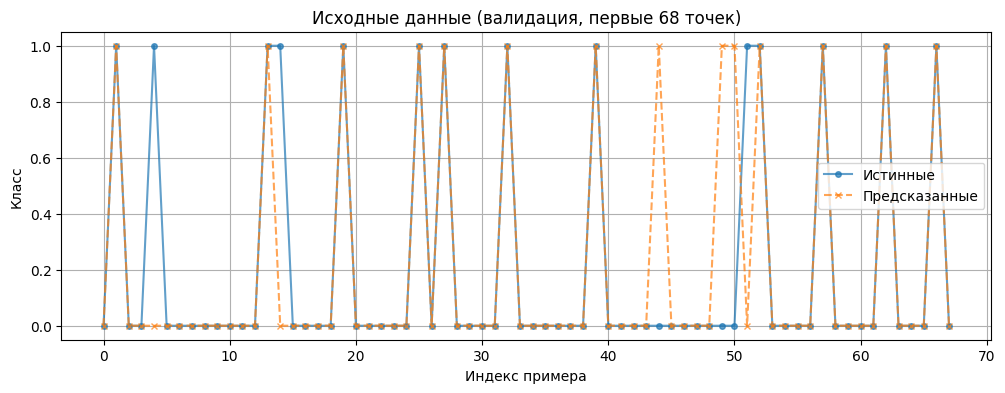

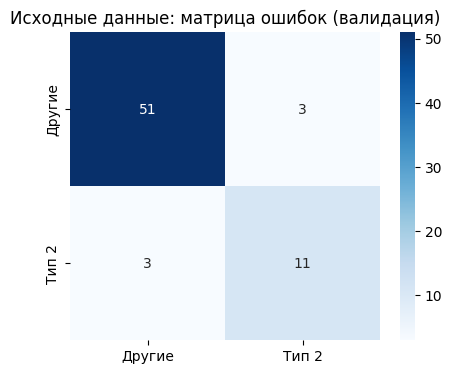

In [366]:
model_orig = MLPClassifier(
    hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
    activation=best_cfg['activation'],
    solver=best_cfg['solver'],
    max_iter=best_cfg['max_iter'],
    alpha=0.0001,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
metrics_orig = evaluate_and_plot(model_orig, X_train, y_train, X_val, y_val, "Исходные данные")

Исходный размер A+B: (176, 27)
После удаления NaN: (169, 27)

--- Сортированные данные ---
Параметры: hls=(50,), act=tanh, solver=lbfgs
CV Accuracy (train): mean=0.8730, std=0.0899
Train: Accuracy=0.9926, F1=0.9831
Val:   Accuracy=0.9412, F1=0.8571


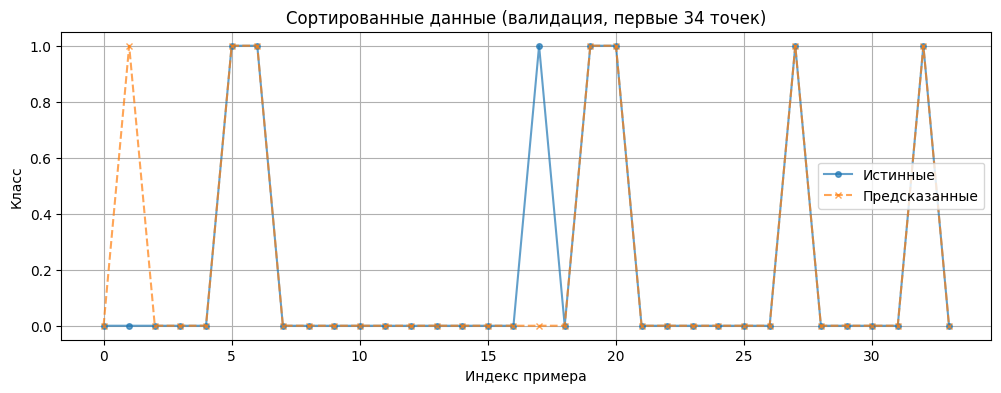

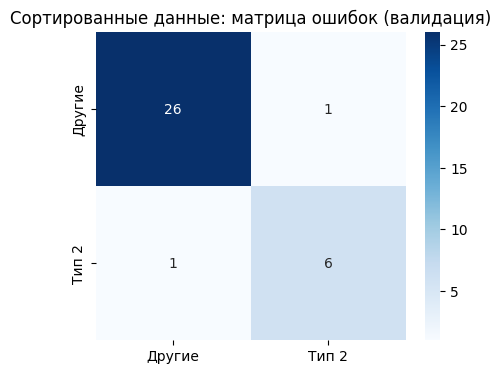

Для дальнейшей работы выбраны СОРТИРОВАННЫЕ данные.


In [367]:
try:
    data_sorted = pd.read_excel('Data_Set_(A+B).xlsx')
    print(f"Исходный размер A+B: {data_sorted.shape}")
    data_sorted = data_sorted.dropna().reset_index(drop=True)
    print(f"После удаления NaN: {data_sorted.shape}")    
    
    data_sorted['Y'] = (data_sorted['Type'] == TARGET_TYPE).astype(int)
    X_sorted = data_sorted[feature_columns].copy()
    y_sorted = data_sorted['Y'].copy()
    # Разделение на train/val (60/40)
    X_tr_s, X_v_s, y_tr_s, y_v_s = train_test_split(
        X_sorted, y_sorted, test_size=0.2, stratify=y_sorted, random_state=RANDOM_STATE)
    
    model_sorted = MLPClassifier(
        hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
        activation=best_cfg['activation'],
        solver=best_cfg['solver'],
        max_iter=best_cfg['max_iter'],
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
    metrics_sorted = evaluate_and_plot(model_sorted, X_tr_s, y_tr_s, X_v_s, y_v_s, "Сортированные данные")
    use_sorted = metrics_sorted['f1_v'] > metrics_orig['f1_v']
except FileNotFoundError:
    use_sorted = False
    metrics_sorted = None
    print("Файл с сортированными данными не найден, пропускаем.")

if use_sorted and metrics_sorted is not None:
    X_train_best, y_train_best, X_val_best, y_val_best = X_tr_s, y_tr_s, X_v_s, y_v_s
    print("Для дальнейшей работы выбраны СОРТИРОВАННЫЕ данные.")
else:
    X_train_best, y_train_best, X_val_best, y_val_best = X_train, y_train, X_val, y_val
    print("Для дальнейшей работы выбраны ИСХОДНЫЕ данные.")

In [368]:
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_best)
X_val_norm = scaler.transform(X_val_best)
X_test_norm = scaler.transform(X_test)

print("Нормализация завершена. Диапазон X_train_norm: [{:.2f}, {:.2f}]".format(
    X_train_norm.min(), X_train_norm.max()))

Нормализация завершена. Диапазон X_train_norm: [0.00, 1.00]



--- Нормализованные данные ---
Параметры: hls=(50,), act=tanh, solver=lbfgs
CV Accuracy (train): mean=0.9182, std=0.0257
Train: Accuracy=1.0000, F1=1.0000
Val:   Accuracy=0.8235, F1=0.5714


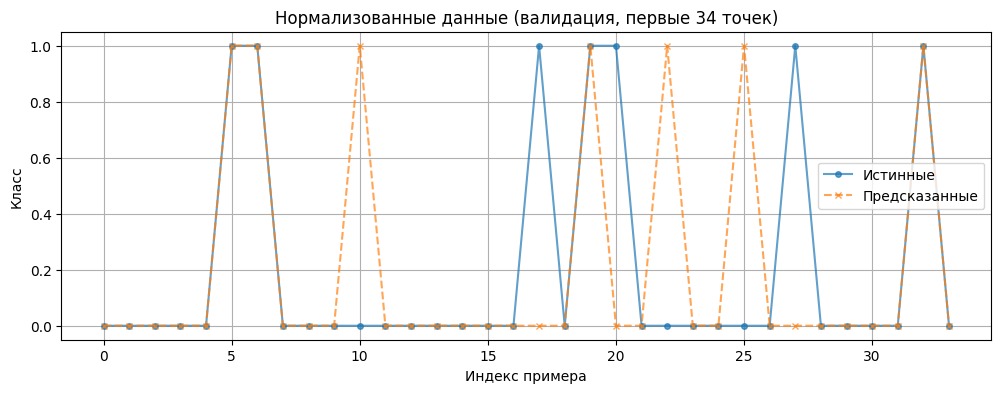

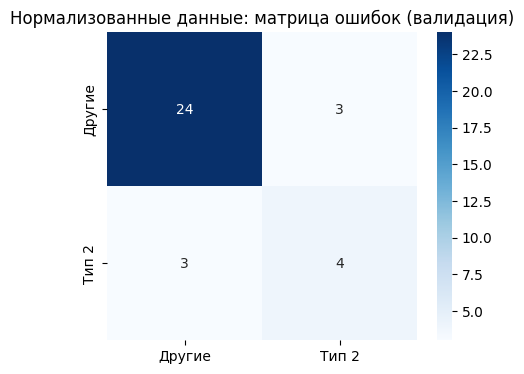

In [369]:
model_norm = MLPClassifier(
    hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
    activation=best_cfg['activation'],
    solver=best_cfg['solver'],
    max_iter=best_cfg['max_iter'],
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
metrics_norm = evaluate_and_plot(model_norm, X_train_norm, y_train_best, X_val_norm, y_val_best,
                                 "Нормализованные данные")

После SMOTE: распределение классов [106 106]

--- SMOTE ---
Параметры: hls=(50,), act=tanh, solver=lbfgs
CV Accuracy (train): mean=0.9575, std=0.0082
Train: Accuracy=1.0000, F1=1.0000
Val:   Accuracy=0.9706, F1=0.9333


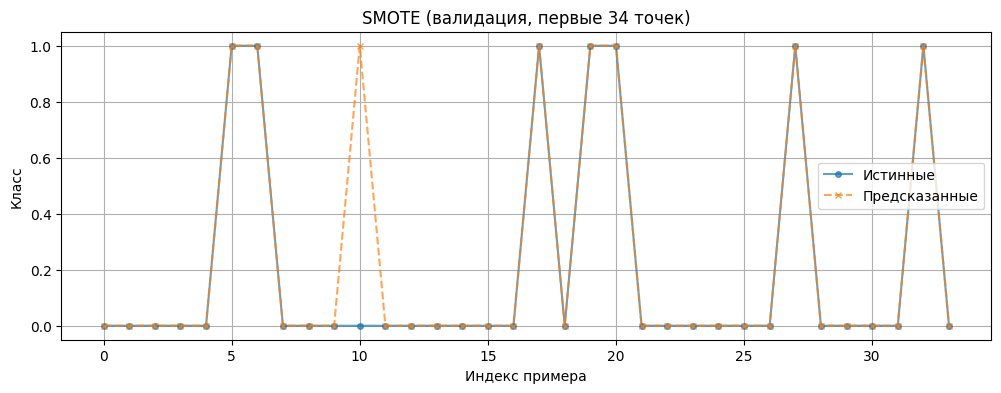

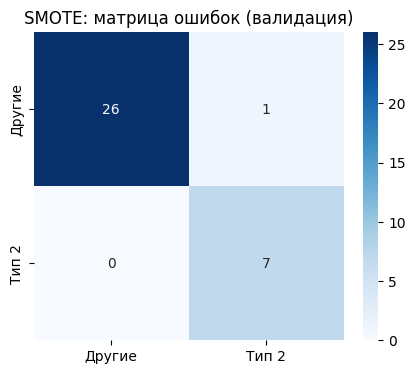

In [370]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_norm, y_train_best)
print("После SMOTE: распределение классов", np.bincount(y_train_sm))

model_sm = MLPClassifier(
    hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
    activation=best_cfg['activation'],
    solver=best_cfg['solver'],
    max_iter=best_cfg['max_iter'],
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
metrics_sm = evaluate_and_plot(model_sm, X_train_sm, y_train_sm, X_val_norm, y_val_best, "SMOTE")


После ADASYN: распределение классов [106 104]

--- ADASYN ---
Параметры: hls=(50,), act=tanh, solver=lbfgs
CV Accuracy (train): mean=0.9429, std=0.0134
Train: Accuracy=1.0000, F1=1.0000
Val:   Accuracy=0.8824, F1=0.7143


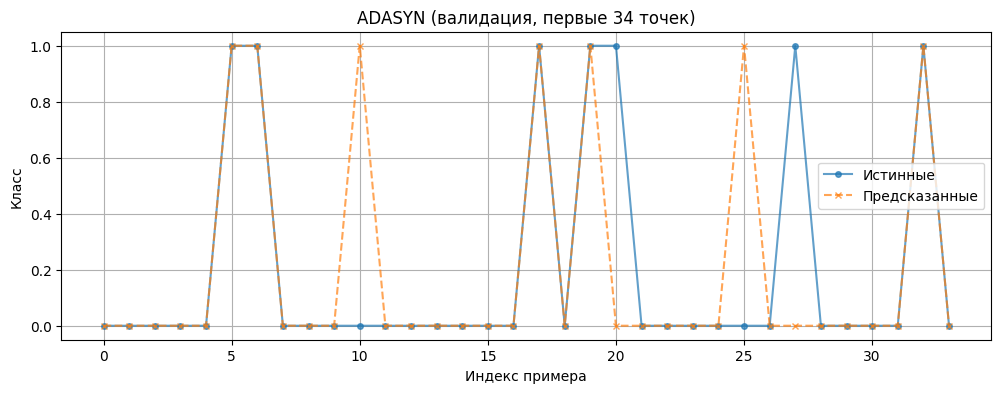

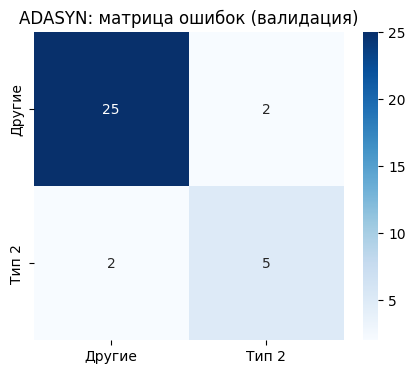

In [371]:
adasyn = ADASYN(random_state=RANDOM_STATE)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_norm, y_train_best)
print("После ADASYN: распределение классов", np.bincount(y_train_ad))

model_ad = MLPClassifier(
    hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
    activation=best_cfg['activation'],
    solver=best_cfg['solver'],
    max_iter=best_cfg['max_iter'],
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
metrics_ad = evaluate_and_plot(model_ad, X_train_ad, y_train_ad, X_val_norm, y_val_best, "ADASYN")


In [372]:
all_metrics = {
    'Original': metrics_orig,
    'Sorted': metrics_sorted if metrics_sorted is not None else None,
    'Normalized': metrics_norm,
    'SMOTE': metrics_sm,
    'ADASYN': metrics_ad
}
all_metrics = {k:v for k,v in all_metrics.items() if v is not None}

print("\n=== Сводка по валидации ===")
for name, m in all_metrics.items():
    print(f"{name:12} | Acc={m['acc_v']:.4f} | F1={m['f1_v']:.4f}")


=== Сводка по валидации ===
Original     | Acc=0.9118 | F1=0.7857
Sorted       | Acc=0.9412 | F1=0.8571
Normalized   | Acc=0.8235 | F1=0.5714
SMOTE        | Acc=0.9706 | F1=0.9333
ADASYN       | Acc=0.8824 | F1=0.7143


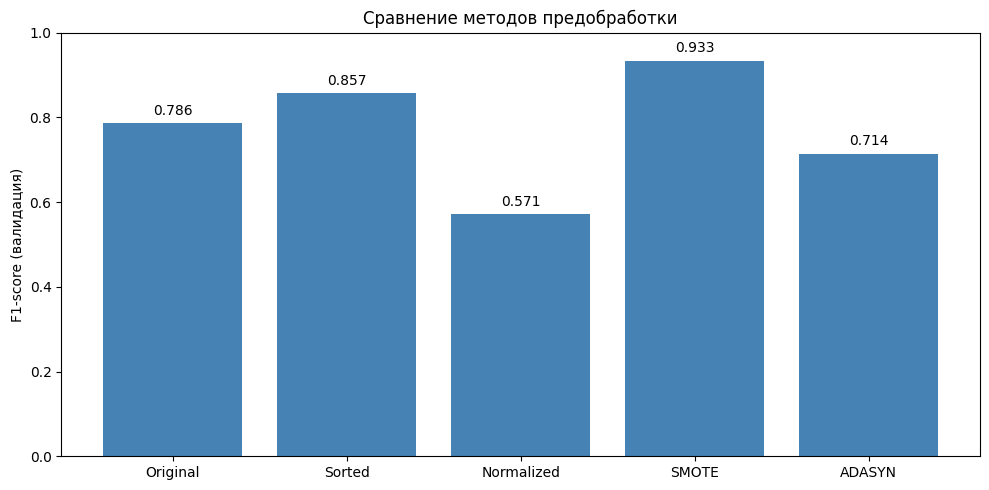


Лучшая модель: SMOTE (F1_val = 0.9333)


In [373]:
plt.figure(figsize=(10,5))
names = list(all_metrics.keys())
f1_vals = [all_metrics[n]['f1_v'] for n in names]
bars = plt.bar(names, f1_vals, color='steelblue')
plt.ylim(0,1); plt.ylabel('F1-score (валидация)'); plt.title('Сравнение методов предобработки')
for bar, val in zip(bars, f1_vals):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.3f}', ha='center')
plt.tight_layout(); plt.savefig('methods_comparison.png', dpi=150); plt.show()

best_method = max(all_metrics, key=lambda x: all_metrics[x]['f1_v'])
print(f"\nЛучшая модель: {best_method} (F1_val = {all_metrics[best_method]['f1_v']:.4f})")


In [374]:
if best_method == 'SMOTE':
    final_model = model_sm
    X_test_final = X_test_norm
elif best_method == 'ADASYN':
    final_model = model_ad
    X_test_final = X_test_norm
elif best_method == 'Normalized':
    final_model = model_norm
    X_test_final = X_test_norm
elif best_method == 'Sorted':
    final_model = model_sorted
    X_test_final = X_test
else:  # Original
    final_model = model_orig
    X_test_final = X_test


In [375]:
y_pred_test = final_model.predict(X_test_final)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print(f"\n=== Контрольная выборка C (модель {best_method}) ===")
print(f"Accuracy = {acc_test:.4f}")
print(f"F1-score = {f1_test:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Другие', f'Тип {TARGET_TYPE}']))



=== Контрольная выборка C (модель SMOTE) ===
Accuracy = 0.8036
F1-score = 0.4211

Classification Report:
              precision    recall  f1-score   support

      Другие       0.84      0.93      0.88        44
       Тип 2       0.57      0.33      0.42        12

    accuracy                           0.80        56
   macro avg       0.70      0.63      0.65        56
weighted avg       0.78      0.80      0.78        56



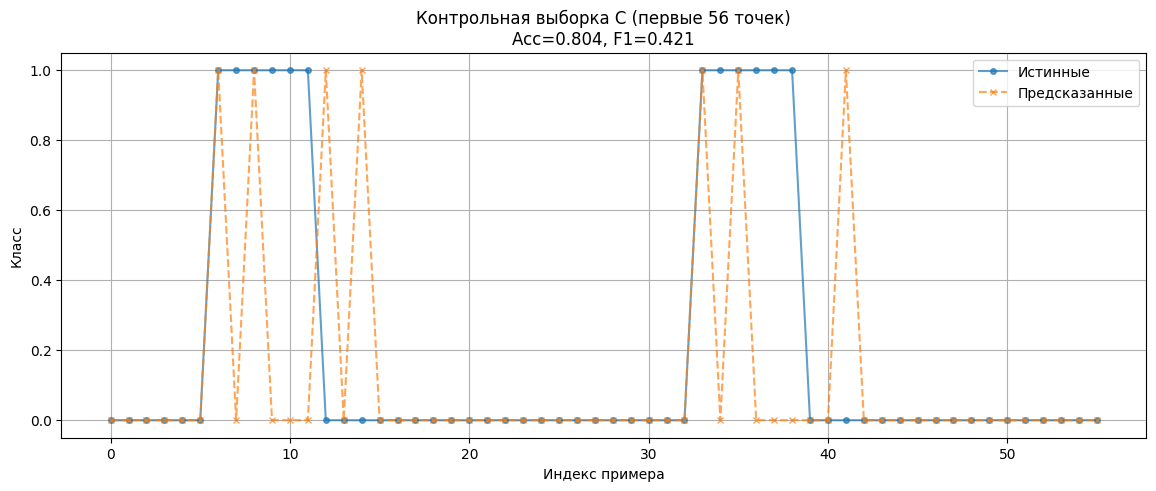

In [376]:
plt.figure(figsize=(14,5))
n_show = min(200, len(y_test))
plt.plot(y_test.values[:n_show], 'o-', label='Истинные', alpha=0.7, markersize=4)
plt.plot(y_pred_test[:n_show], 'x--', label='Предсказанные', alpha=0.7, markersize=4)
plt.title(f'Контрольная выборка C (первые {n_show} точек)\nAcc={acc_test:.3f}, F1={f1_test:.3f}')
plt.xlabel('Индекс примера'); plt.ylabel('Класс'); plt.legend(); plt.grid(True)
plt.show()


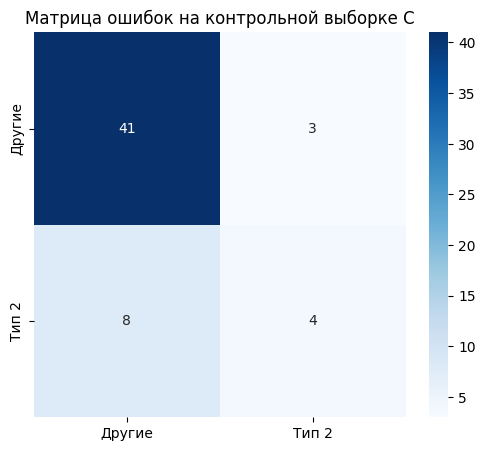


Лабораторная работа №3 выполнена.


In [377]:
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Другие', f'Тип {TARGET_TYPE}'],
            yticklabels=['Другие', f'Тип {TARGET_TYPE}'])
plt.title('Матрица ошибок на контрольной выборке C')
plt.show()

print("\nЛабораторная работа №3 выполнена.")